

# Removing muscle ICA components

Gross movements produce widespread high-frequency activity across all channels
that is usually not recoverable and so the epoch must be rejected as shown in
`ex-muscle-artifacts`. More ubiquitously than gross movements, muscle
artifact is produced during postural maintenance. This is more appropriately
removed by ICA otherwise there wouldn't be any epochs left! Note that muscle
artifacts of this kind are much more pronounced in EEG than they are in MEG.


In [1]:
pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 61.8 MB/s eta 0:00:00


In [2]:
pip install python-picard

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for python-picard: filename=python_picard-0.8-py3-none-any.whl size=16394 sha256=22cd5852c9cf97176ef313f09c19d050a7477d41d25d777895fd0a5bf3a149a9
  Stored in directory: /root/.cache/pip/wheels/c3/43/5e/501cefd2d8a40f4fff96a84acc25ddf803ca44c6ec54d8b273
Successfully built python-picard


Creating RawArray with float64 data, n_channels=8, n_times=180227
    Range : 0 ... 180226 =      0.000 ...   720.904 secs
Ready.

Recortando los datos del segundo 30 al 60...

Generando gráfico del PSD de los datos crudos (ANTES)...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).

Aplicando filtro Pasa-Banda (1-55 Hz)...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 55 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 55.00 Hz
- Upper transition bandwidth: 13.75 Hz (-6 dB cutoff frequency: 61.88 Hz)
- Filter length: 825 samples (3.300 s)

Apli

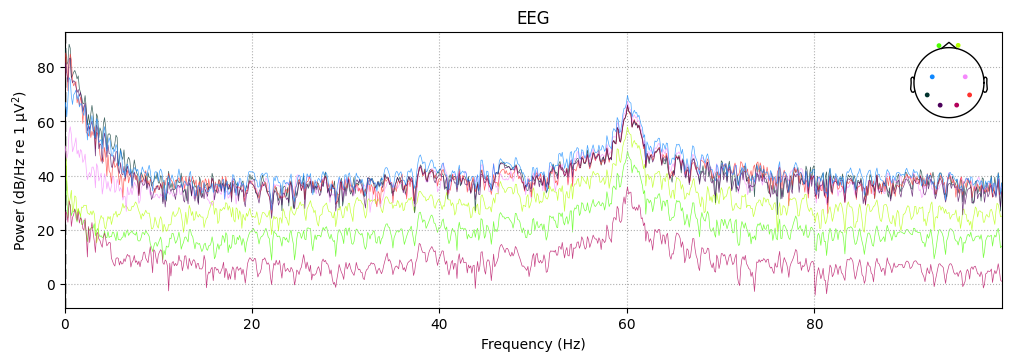

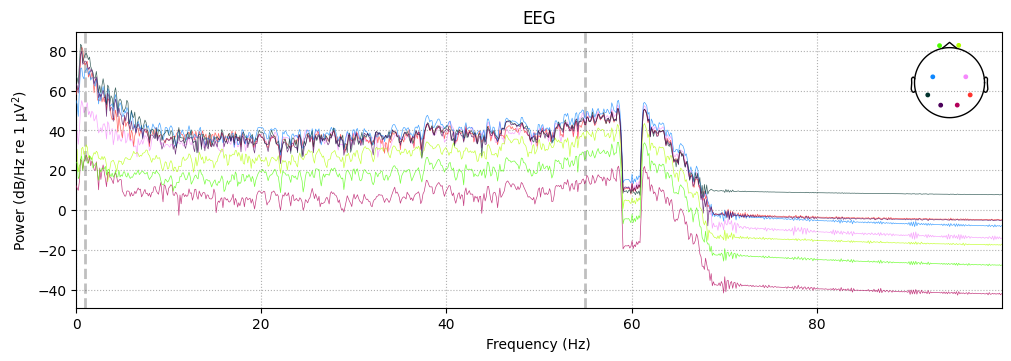

In [64]:
import mne
import pandas as pd
import numpy as np

# ===================================================================
# PASO 1: CARGAR Y PREPARAR LOS DATOS DEL CORTEX
# ===================================================================

# Especifica la ruta a tu archivo de datos.
fname = 'OpenBCI-RAW-2025-09-17_12-45-51.txt'

sfreq = 250  # Tasa de muestreo en Hz


df = pd.read_csv(fname, comment='%')
df.columns = df.columns.str.strip()

# Extraer los datos.
original_ch_names = [f'EXG Channel {i}' for i in range(8)]
data = df[original_ch_names].values

# Transformar los datos Volts.
data_in_volts = data.T * 1e-6

# Crear los nombres originales
ch_types = ['eeg'] * len(original_ch_names)
info = mne.create_info(ch_names=original_ch_names, sfreq=sfreq, ch_types=ch_types)

#Crear el array
raw = mne.io.RawArray(data_in_volts, info)

# Renombrar los canales a la nomenclatura estándar 10-20.
mapping = {
    'EXG Channel 0': 'Fp1', 'EXG Channel 1': 'Fp2', 'EXG Channel 2': 'C3',
    'EXG Channel 3': 'C4', 'EXG Channel 4': 'P7', 'EXG Channel 5': 'P8',
    'EXG Channel 6': 'O1', 'EXG Channel 7': 'O2'
}
raw.rename_channels(mapping)

# Aasignar el montaje mne
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)


# --- INICIO DE LA MODIFICACIÓN ---
# Recortar 30 segundos, en este caso de 30 a 60 para no sacar toda la duración de la grabación
print("\nRecortando los datos del segundo 30 al 60...")
raw.crop(tmin=30, tmax=60)
# --- FIN DE LA MODIFICACIÓN ---


# ===================================================================
# PASO 2: VISUALIZAR Y FILTRAR LOS DATOS
# ===================================================================

#Guardar una copia de los datos SIN FILTRAR para poder comparar.
raw_unfiltered = raw.copy()

#Graficar el PSD de los datos originales (ANTES de filtrar)
print("\nGenerando gráfico del PSD de los datos crudos (ANTES)...")
raw_unfiltered.plot_psd(fmax=100)

#Cargar los datos en memoria para el filtrado.
raw.load_data()

# Aplicar un filtro pasabanda, aca se considera un filtro hasta 55 Hz para tambien considerar las ondas Gamma de 45 Hz
print("\nAplicando filtro Pasa-Banda (1-55 Hz)...")
raw = raw.filter(l_freq=1.0, h_freq=55.0)

# Aplicar un filtro Notch para eliminar el ruido de 60 Hz
print("Aplicando filtro Notch preciso en 60 Hz...")
raw = raw.notch_filter(freqs=60, notch_widths=2)

# 16. Grafica el PSD de los datos ya filtrados (DESPUÉS)
print("\nGenerando gráfico del PSD de los datos YA FILTRADOS (DESPUÉS)...")
raw.plot_psd(fmax=100)

# 17. Imprime el resumen final.
print("\n--- RESUMEN DE LOS DATOS CARGADOS Y FILTRADOS ---")
print(raw)

Run ICA



In [57]:
# --- APLICAR ICA

ica = mne.preprocessing.ICA(
    n_components=8,
    method="picard",
    max_iter="auto",
    random_state=97
)


ica.fit(raw)


print("\n--- Resumen del ICA Ajustado los datos del cortex ---")
print(ica)

Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by number: 8 components
Fitting ICA took 1.4s.

--- Resumen del ICA Ajustado los datos del cortex ---
<ICA | raw data decomposition, method: picard (fit in 56 iterations on 7501 samples), 8 ICA components (8 PCA components available), channel types: eeg, no sources marked for exclusion>


/tmp/ipython-input-566273877.py:11: RuntimeWarning: Using n_components=8 (resulting in n_components_=8) may lead to an unstable mixing matrix estimation because the ratio between the largest (6.5) and smallest (4e-06) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 7
  ica.fit(raw)


Remove components with postural muscle artifact using ICA




Mostrando los primeros 30 segundos de los componentes ICA:
Creating RawArray with float64 data, n_channels=8, n_times=7501
    Range : 7500 ... 15000 =     30.000 ...    60.000 secs
Ready.


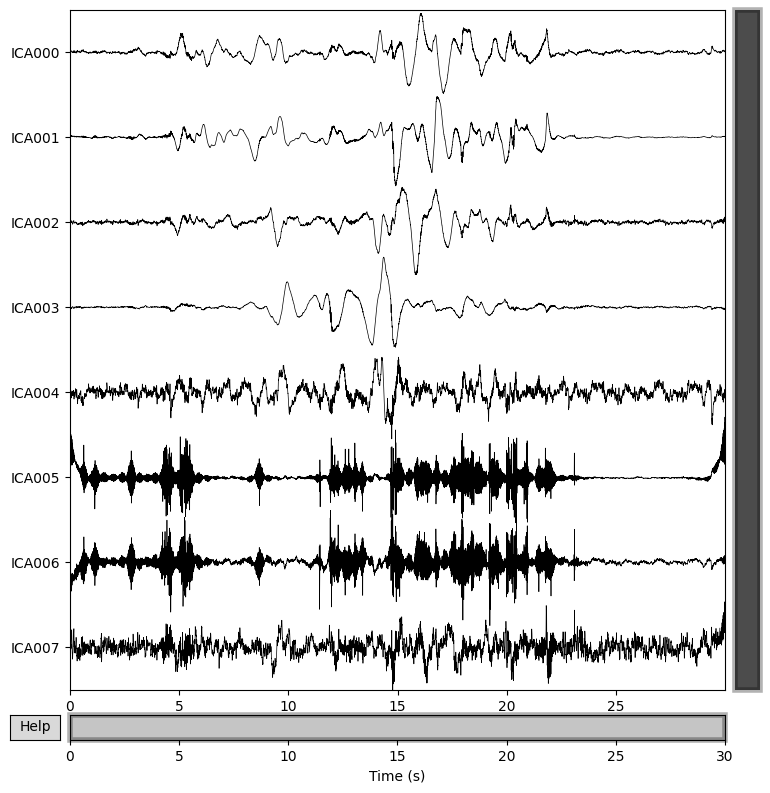

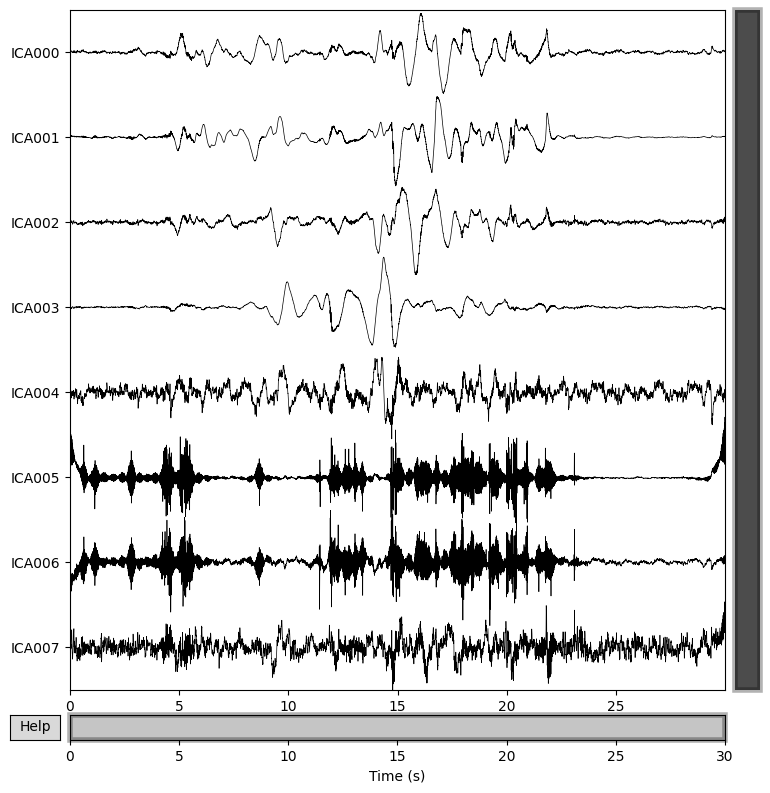

In [58]:
print("\nMostrando los primeros 30 segundos de los componentes ICA:")
ica.plot_sources(raw, start=0, stop=30)

By inspection, let's select out the muscle-artifact components based on
:footcite:`DharmapraniEtAl2016` manually.

The criteria are:

- Positive slope of log-log power spectrum between 7 and 75 Hz
  (here just flat because it's not in log-log)
- Peripheral focus or dipole/multi-pole foci (the blue and red
  blobs in the topomap are far from the vertex where the most
  muscle is)
- Single focal point (low spatial smoothness; there is just one focus
  of the topomap compared to components like the first ones that are
  more likely neural which spread across the topomap)

The other attribute worth noting is that the time course in
:func:`mne.preprocessing.ICA.plot_sources` looks like EMG; you can
see spikes when each motor unit fires so that the time course looks fuzzy
and sometimes has large spikes that are often at regular intervals.

ICA component 13 is a textbook example of what muscle artifact looks like.
The focus of the topomap for this component is right on the temporalis
muscle near the ears. There is also a minimum in the power spectrum at around
10 Hz, then a maximum at around 25 Hz, generally resulting in a positive
slope in log-log units; this is a very typical pattern for muscle artifact.



    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated


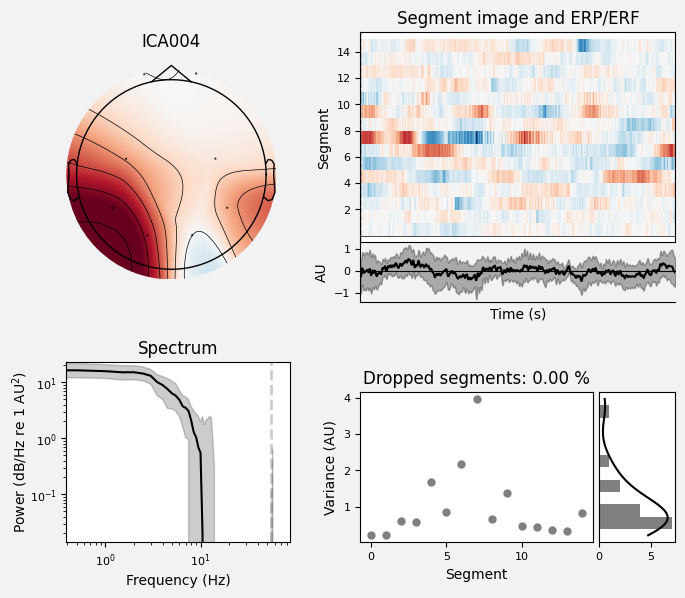

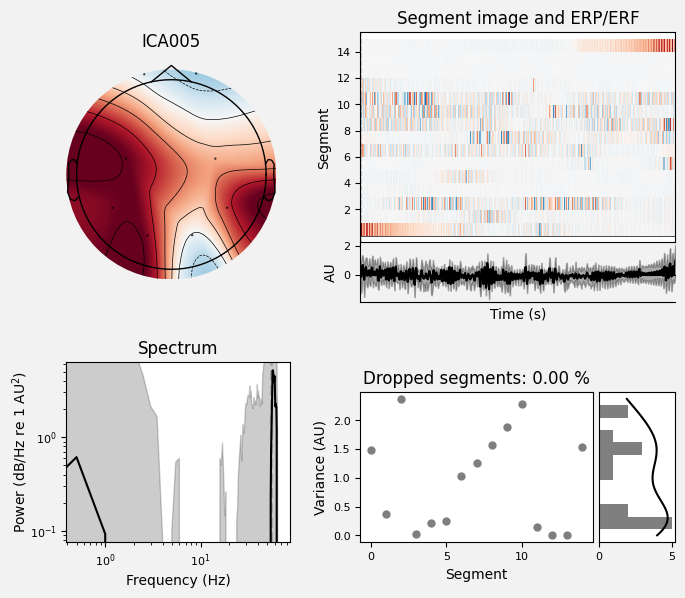

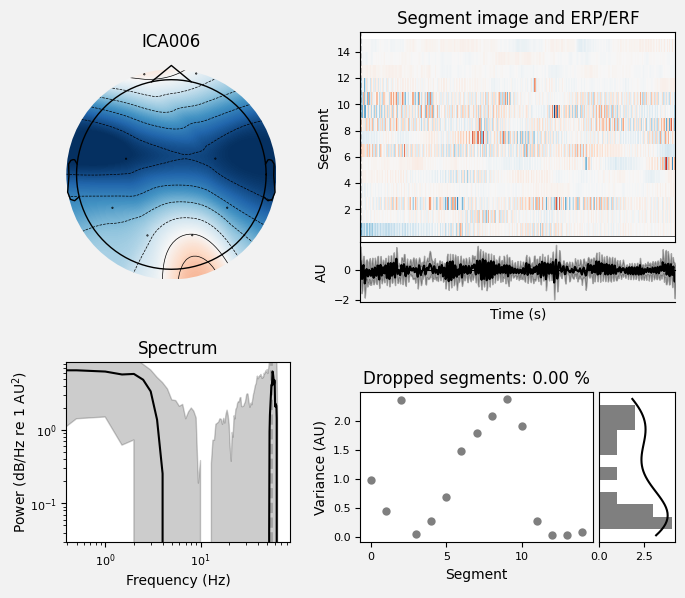

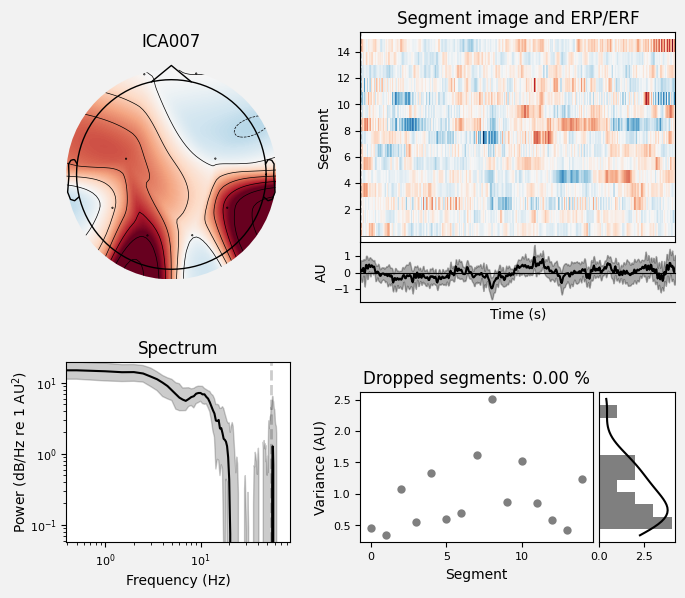

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

In [59]:
#En base a los resultados del ICA se aprecia actividad en los ICA 004, 005, 006 Y 007


idx = [4, 5, 6, 7]
ica.plot_properties(raw, picks=idx, log_scale=True)

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated


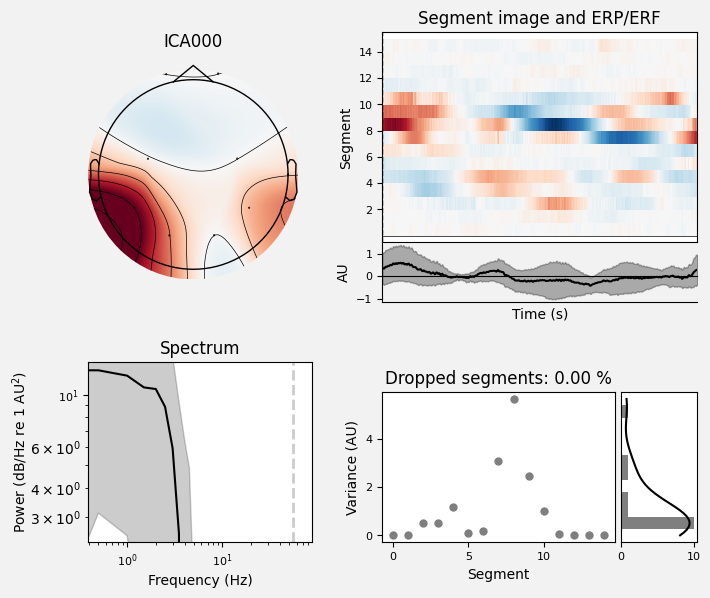

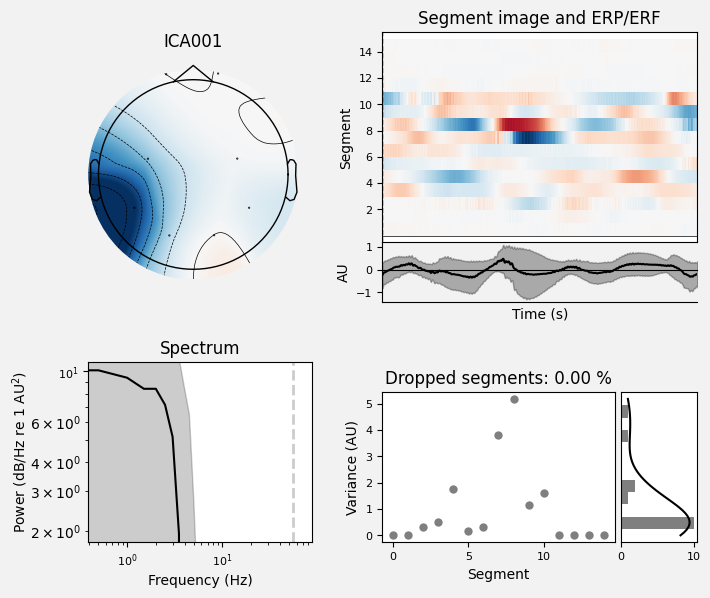

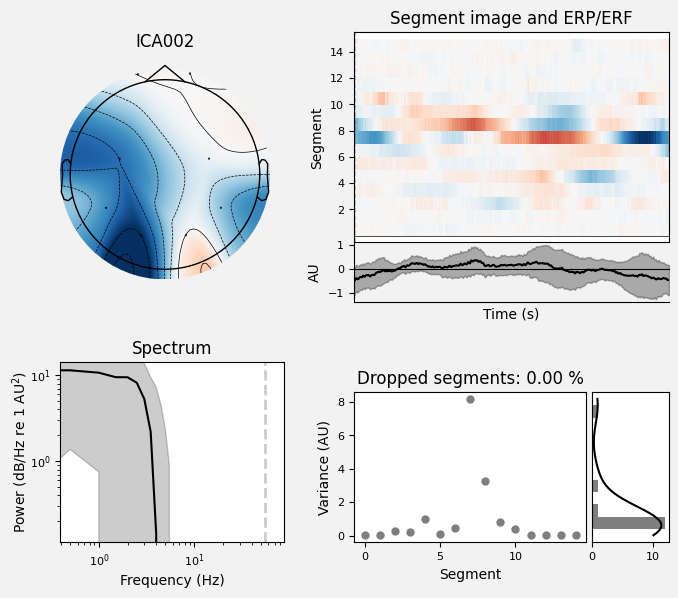

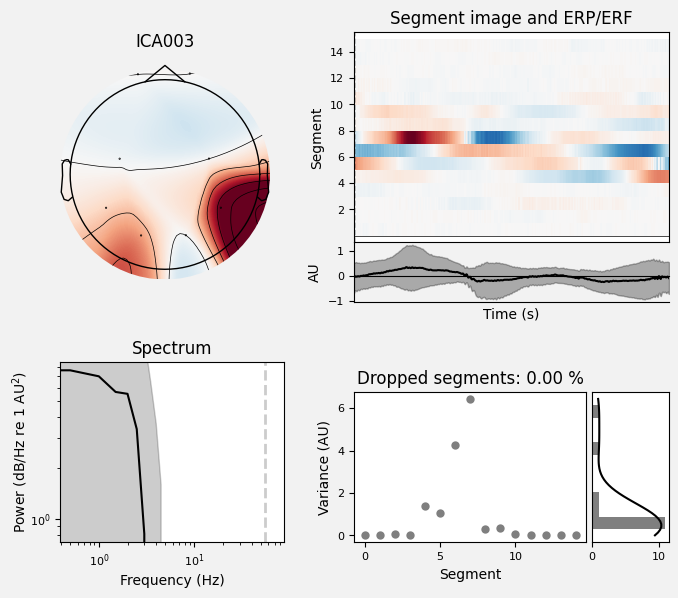

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 2 ICA components
    Projecting back using 8 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 4 ICA components
    Projecting back using 8 PCA components


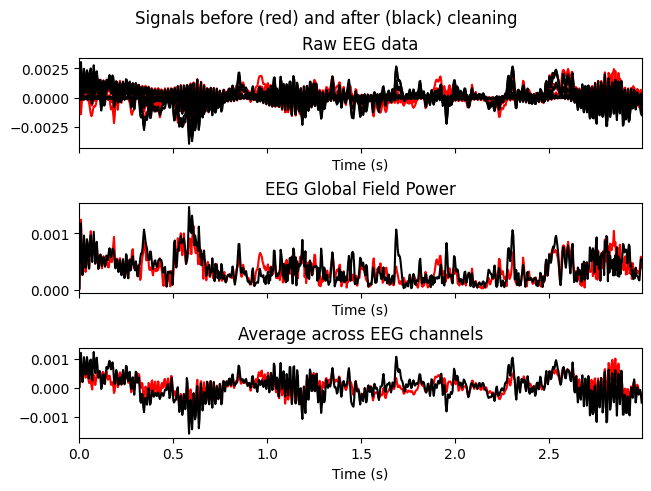

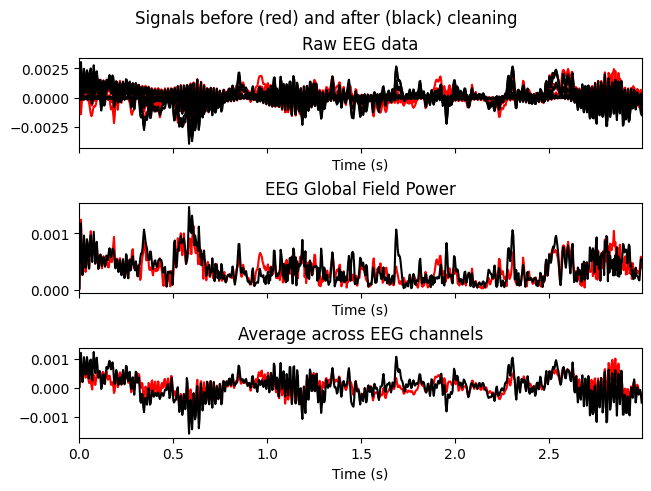

In [60]:
muscle_idx = [0,1,2,3]
ica.plot_properties(raw, picks=muscle_idx, log_scale=True)

# first, remove blinks and heartbeat to compare
blink_idx = [0]
heartbeat_idx = [5]
ica.apply(raw, exclude=blink_idx + heartbeat_idx)
ica.plot_overlay(raw, exclude=muscle_idx)

Finally, let's try an automated algorithm to find muscle components
and ensure that it gets the same components we did manually.



Effective window size : 8.192 (s)


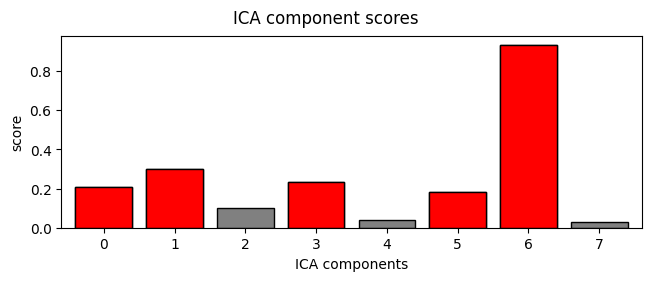

Manually found muscle artifact ICA components:      [0, 1, 2, 3]
Automatically found muscle artifact ICA components: [0, 1, 3, 5, 6]


In [61]:
muscle_idx_auto, scores = ica.find_bads_muscle(raw)
ica.plot_scores(scores, exclude=muscle_idx_auto)
print(
    f"Manually found muscle artifact ICA components:      {muscle_idx}\n"
    f"Automatically found muscle artifact ICA components: {muscle_idx_auto}"
)

## Let's now replicate this on the EEGBCI dataset



## References

Dhani Dharmaprani, Hoang K. Nguyen, Trent W. Lewis, Dylan DeLosAngeles, John O. Willoughby, and Kenneth J. Pope. A comparison of independent component analysis algorithms and measures to discriminate between EEG and artifact components. In 2016 38th Annual International Conference of the IEEE Engineering in Medicine and Biology Society (EMBC), 825–828. Orlando, FL, USA, 2016. IEEE. doi:10.1109/EMBC.2016.7590828.

